In [32]:
"""
案例:
    演示CNN的综合案例, 图像分类.

回顾: 深度学习项目的步骤
    1. 准备数据集.
        这里我们用的时候 计算机视觉模块 torchvision自带的 CIFAR10数据集, 包含6W张 (32,32,3)的图片, 5W张训练集, 1W张测试集, 10个分类, 每个分类6K张图片.
        你需要单独安装一下 torchvision包, 即: pip install torchvision
    2. 搭建(卷积)神经网络
    3. 模型训练.
    4. 模型测试.

卷积层:
    提取图像的局部特征 -> 特征图(Feature Map), 计算方式:  N = (W - F + 2P) // S + 1
    每个卷积核都是1个神经元.

池化层:
    降维, 有最大池化 和 平均池化.
    池化只在HW上做调整, 通道上不改变.

案例的优化思路:
    1. 增加卷积核的输出通道数(大白话: 卷积核的数量)
    2. 增加全连接层的参数量.
    3. 调整学习率
    4. 调整优化方法(optimizer...)
    5. 调整激活函数...
    6. ...
"""

'\n案例:\n    演示CNN的综合案例, 图像分类.\n\n回顾: 深度学习项目的步骤\n    1. 准备数据集.\n        这里我们用的时候 计算机视觉模块 torchvision自带的 CIFAR10数据集, 包含6W张 (32,32,3)的图片, 5W张训练集, 1W张测试集, 10个分类, 每个分类6K张图片.\n        你需要单独安装一下 torchvision包, 即: pip install torchvision\n    2. 搭建(卷积)神经网络\n    3. 模型训练.\n    4. 模型测试.\n\n卷积层:\n    提取图像的局部特征 -> 特征图(Feature Map), 计算方式:  N = (W - F + 2P) // S + 1\n    每个卷积核都是1个神经元.\n\n池化层:\n    降维, 有最大池化 和 平均池化.\n    池化只在HW上做调整, 通道上不改变.\n\n案例的优化思路:\n    1. 增加卷积核的输出通道数(大白话: 卷积核的数量)\n    2. 增加全连接层的参数量.\n    3. 调整学习率\n    4. 调整优化方法(optimizer...)\n    5. 调整激活函数...\n    6. ...\n'

In [2]:
# 导包
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor  # pip install torchvision -i https://mirrors.aliyun.com/pypi/simple/
import torch.optim as optim
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt
from torchsummary import summary

# 每批次样本数
BATCH_SIZE = 8

In [3]:
# 1.准备数据集
def create_dataset():
    # 1.获取训练集
    train_dataset=CIFAR10(root='./data',train=True,transform=ToTensor(),download=True)
    # 2.获取测试集
    test_dataset=CIFAR10(root='./data',train=False,transform=ToTensor(),download=True)
    # 3.返回数据集
    return train_dataset,test_dataset

train_dataset,test_dataset=create_dataset()
print(f'训练集：{train_dataset.data.shape}')
print(f'测试集：{test_dataset.data.shape}')
print(f'数据集类别：{train_dataset.class_to_idx}')

训练集：(50000, 32, 32, 3)
测试集：(10000, 32, 32, 3)
数据集类别：{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


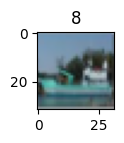

In [35]:
# 图像展示
plt.figure(figsize=(1,1))
n=111
plt.imshow(train_dataset.data[n])      # 索引为111的图像
plt.title(train_dataset.targets[n])
plt.show()

In [5]:
# 2. 搭建(卷积)神经网络
class ImageModel(nn.Module):
    # 1. 初始化父类成员, 搭建神经网络.
    def __init__(self):
        # 1.1 初始化父类成员.
        super().__init__()
        # 1.2 搭建神经网络.
        # 第1个卷积层, 输入 3通道, 输出6通道, 卷积核大小3*3, 步长1, 填充0
        self.conv1 = nn.Conv2d(3, 6, 3, 1, 0)
        # 第1个池化层, 窗口大小 2*2, 步长2, 填充0
        self.pool1 = nn.MaxPool2d(2, 2, 0)

        # 第2个卷积层, 输入 6通道, 输出16通道, 卷积核大小3*3, 步长1, 填充0
        self.conv2 = nn.Conv2d(6, 16, 3, 1, 0)
        # 第2个池化层, 窗口大小 2*2, 步长2, 填充0
        self.pool2 = nn.MaxPool2d(2, 2, 0)

        # 第1个隐藏层(全连接层), 输入: 576, 输出: 120
        self.linear1 = nn.Linear(576, 120)
        # 第2个隐藏层 (全连接层), 输入: 120, 输出: 84
        self.linear2 = nn.Linear(120, 84)
        # 第3个隐藏层 (全连接层) -> 输出层,  输入: 84, 输出: 10
        self.output = nn.Linear(84, 10)

    # 2. 定义前向传播
    def forward(self, x):
        # 第1层: 卷积层(加权求和) + 激励层(激活函数) + 池化层(降维)
        # 分解版.
        # x = self.conv1(x)   # 卷积层
        # x = torch.relu(x)   # 激励层
        # x = self.pool1(x)   # 池化层

        # 合并版   池化   +  激活函数  +  卷积
        x = self.pool1(torch.relu(self.conv1(x)))

        # 第2层: 卷积层(加权求和) + 激励层(激活函数) + 池化层(降维)
        x = self.pool2(torch.relu(self.conv2(x)))

        # 细节: 全连接层只能处理二维数据, 所以要将数据进行拉平 (8, 16, 6, 6) ->  (8, 576)
        # 参1: 样本数(行数), 参2: 列数(特征数), -1表示自动计算.
        x = x.reshape(x.size(0), -1)  # 8行576列
        # print(f'x.shape: {x.shape}')

        # 第3层: 全连接层(加权求和) + 激励层(激活函数)
        x = torch.relu(self.linear1(x))

        # 第4层: 全连接层(加权求和) + 激励层(激活函数)
        x = torch.relu(self.linear2(x))

        # 第5层: 全连接层(加权求和) -> 输出层
        return self.output(x)  # 后续用 多分类交叉熵损失函数CrossEntropyLoss = softmax()激活函数 + 损失计算.

model=ImageModel()
summary(model, (3,32,32),batch_size=BATCH_SIZE)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1             [8, 6, 30, 30]             168
         MaxPool2d-2             [8, 6, 15, 15]               0
            Conv2d-3            [8, 16, 13, 13]             880
         MaxPool2d-4              [8, 16, 6, 6]               0
            Linear-5                   [8, 120]          69,240
            Linear-6                    [8, 84]          10,164
            Linear-7                    [8, 10]             850
Total params: 81,302
Trainable params: 81,302
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.09
Forward/backward pass size (MB): 0.63
Params size (MB): 0.31
Estimated Total Size (MB): 1.03
----------------------------------------------------------------


In [37]:
def train(train_dataset):
    # 1.创建数据加载器
    dataloader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
    # 2.创建模型对象
    model=ImageModel()
    # 3.创建损失函数
    criterion=nn.CrossEntropyLoss()   # 多分类交叉熵损失函数 = softmax()激活函数 + 损失计算.
    # 4. 创建优化器对象.
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 5.循环遍历epoch，开始每轮的训练动作
    # 5.1 定义变量, 记录训练的总轮数.
    epochs = 20
    # 5.2 遍历, 完成每轮的 所有批次的 训练动作.
    for epoch_idx in range(epochs):
        # 5.2.1 定义变量, 记录: 总损失, 总样本数据量, 预测正确样本个数, 训练(开始)时间
        total_loss, total_samples, total_correct, start = 0.0, 0, 0, time.time()
        # 5.2.2 遍历数据加载器, 获取到 每批次的 数据.
        for x,y in dataloader:
            # 5.2.3 切换训练模式.
            model.train()
            # 5.2.4 模型预测.
            y_pred = model(x)
            # 5.2.5 计算损失.
            loss=criterion(y_pred,y)
            # 5.2.6 梯度清零 + 反向传播 + 参数更新
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # 5.2.7 统计预测正确的样本个数.
            total_correct += (torch.argmax(y_pred, dim=-1) == y).sum()

            # 5.2.8 统计当前批次的总损失.          第1批平均损失 * 第1批样本个数
            total_loss += loss.item() * len(y)  # [第1批总损失 +  第2批总损失 +  第3批总损失 +  ...]
            # 5.2.9  统计当前批次的总样本个数.
            total_samples += len(y)
            # break   # 每轮只训练1批, 提高训练效率, 减少训练时长, 只有测试会这么写, 实际开发绝不要这样做.

        # 5.2.10 走这里, 说明一轮训练完毕, 打印该轮的训练信息.
        print(f'epoch: {epoch_idx+1}, loss: {total_loss / total_samples:.5f}, acc:{total_correct / total_samples:.2f}, time:{time.time() - start:.2f}s')

    # 6.保存模型.
    torch.save(model.state_dict(), 'image_classification.pth')
train(train_dataset)

epoch: 1, loss: 1.64520, acc:0.39, time:38.03s
epoch: 2, loss: 1.34599, acc:0.51, time:31.16s
epoch: 3, loss: 1.23782, acc:0.56, time:40.30s
epoch: 4, loss: 1.17535, acc:0.58, time:61.26s
epoch: 5, loss: 1.12439, acc:0.60, time:47.83s
epoch: 6, loss: 1.08466, acc:0.61, time:49.43s
epoch: 7, loss: 1.05344, acc:0.63, time:41.05s
epoch: 8, loss: 1.02600, acc:0.64, time:37.40s
epoch: 9, loss: 0.99821, acc:0.65, time:45.93s
epoch: 10, loss: 0.97376, acc:0.66, time:37.05s
epoch: 11, loss: 0.95075, acc:0.66, time:36.67s
epoch: 12, loss: 0.93004, acc:0.67, time:41.71s
epoch: 13, loss: 0.91574, acc:0.67, time:40.23s
epoch: 14, loss: 0.89487, acc:0.68, time:36.92s
epoch: 15, loss: 0.88220, acc:0.69, time:37.65s
epoch: 16, loss: 0.86761, acc:0.69, time:39.00s
epoch: 17, loss: 0.85197, acc:0.69, time:38.76s
epoch: 18, loss: 0.83788, acc:0.70, time:36.60s
epoch: 19, loss: 0.82700, acc:0.71, time:39.37s
epoch: 20, loss: 0.81919, acc:0.71, time:41.25s


In [6]:
def evaluate(test_dataset):
    # 1.创建测试集，数据加载器
    dataloader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)
    # 2.创建模型对象
    model=ImageModel()
    # 3.加载模型参数
    model.load_state_dict(torch.load('image_classification.pth'))
    # 4. 定义变量统计 预测正确的样本个数, 总样本个数.
    total_correct, total_samples = 0, 0
    # 5. 遍历数据加载器, 获取到 每批次 的数据.
    for x, y in dataloader:
        # 5.1 切换模型模式.
        model.eval()
        # 5.2 模型预测.
        y_pred = model(x)
        # 5.3 因为训练的时候用了CrossEntropyLoss, 所以搭建神经网络时没有加softmax()激活函数, 这里要用 argmax()来模拟.
        # argmax()函数功能:  返回最大值对应的索引, 充当 -> 该图片的 预测分类.
        y_pred = torch.argmax(y_pred, dim=-1)   # -1 这里表示行.
        # 5.4 统计预测正确的样本个数.
        total_correct += (y_pred == y).sum()
        # 5.5 统计总样本个数.
        total_samples += len(y)
    
    # 6. 打印正确率(预测结果).
    print(f'Acc: {total_correct / total_samples:.2f}')

evaluate(test_dataset)

Acc: 0.61
